In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vehicle-sales-data/car_prices.csv


In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [3]:
d=pd.read_csv("/kaggle/input/vehicle-sales-data/car_prices.csv")
d

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,in,45.0,18255.0,silver,black,avis corporation,35300.0,33000.0,Thu Jul 09 2015 07:00:00 GMT-0700 (PDT)
558833,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,54393.0,white,black,i -5 uhlmann rv,30200.0,30800.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558834,2012,BMW,X5,xDrive35d,SUV,automatic,5uxzw0c58cl668465,ca,48.0,50561.0,black,black,financial services remarketing (lease),29800.0,34000.0,Wed Jul 08 2015 09:30:00 GMT-0700 (PDT)
558835,2015,Nissan,Altima,2.5 S,sedan,automatic,1n4al3ap0fc216050,ga,38.0,16658.0,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,Thu Jul 09 2015 06:45:00 GMT-0700 (PDT)


In [4]:
d.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [5]:
d['transmission'].unique()

array(['automatic', nan, 'manual', 'Sedan', 'sedan'], dtype=object)

In [6]:
cat_cols = d.select_dtypes(include='object').columns

d[cat_cols] = d[cat_cols].apply(lambda x: x.str.lower().str.strip())

In [7]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [8]:
d.isna().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [9]:
d.columns.tolist()

['year',
 'make',
 'model',
 'trim',
 'body',
 'transmission',
 'vin',
 'state',
 'condition',
 'odometer',
 'color',
 'interior',
 'seller',
 'mmr',
 'sellingprice',
 'saledate']

In [10]:
d['color'].unique()

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', nan, 'orange', 'off-white', 'turquoise', 'pink',
       'lime', '4802', '9410', '1167', '2172', '14872', '12655', '15719',
       '6388', '16633', '11034', '2711', '6864', '339', '18384', '9887',
       '9837', '20379', '20627', '721', '6158', '2817', '5705', '18561',
       '2846', '9562', '5001'], dtype=object)

In [11]:
columns = [
    "year",          # سنة الصنع
    "make",          # الشركة المصنعة
    "model",         # اسم الموديل
    "trim",          # فئة السيارة
    "body",          # نوع الهيكل
    "transmission",  # نوع الجير
    "vin",           # رقم الشاصي
    "state",         # الولاية/الموقع
    "condition",     # حالة السيارة
    "odometer",      # عداد المسافة
    "color",         # لون خارجي
    "interior",      # لون داخلي
    "seller",        # اسم البائع
    "mmr",           # سعر تقديري
    "sellingprice",  # سعر البيع
    "saledate"       # تاريخ البيع
]

In [12]:
cols_to_fill = [
    'make', 'model', 'trim', 'body', 'transmission',
    'condition', 'color', 'interior'
]


d['vin'] = d['vin'].astype(str).str[:3]


for col in cols_to_fill:
    vin_map = d[d[col].notna()].drop_duplicates(subset='vin')[
        ['vin', col]
    ]
    vin_dict = dict(zip(vin_map['vin'], vin_map[col]))
    d[col] = d.apply(
        lambda row: vin_dict.get(row['vin'], row[col]),
        axis=1
    )

In [13]:
d.isna().sum()

year              0
make             22
model            22
trim             22
body            396
transmission      8
vin               0
state             0
condition        26
odometer         94
color             0
interior          0
seller            0
mmr              38
sellingprice     12
saledate         12
dtype: int64

In [14]:
d = d[d['vin'].notna()]

In [15]:
for col in ['make', 'model', 'trim', 'body', 'transmission']:
    d[col].fillna(d[col].mode()[0], inplace=True)

In [16]:
for col in ['condition', 'odometer', 'mmr', 'sellingprice']:
    d[col].fillna(d[col].median(), inplace=True)

In [17]:
d.isna().sum()

year             0
make             0
model            0
trim             0
body             0
transmission     0
vin              0
state            0
condition        0
odometer         0
color            0
interior         0
seller           0
mmr              0
sellingprice     0
saledate        12
dtype: int64

In [18]:
d.duplicated().sum()

np.int64(0)

In [19]:
d['price_diff'] = d['sellingprice'] - d['mmr']#حساب الفارق بين السعر الفعلي والقيمة التقديرية
d['price_ratio'] = d['sellingprice'] / d['mmr']#حساب نسبة السعر بالنسبة للقيمة التقديرية
d['price_deviation_percent'] = ((d['sellingprice'] - d['mmr']) / d['mmr']) * 100#حساب انحراف السعر بالنسبة للقيمة التقديريلـ %

In [20]:
d

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,price_diff,price_ratio,price_deviation_percent
0,2015,kia,sorento,lx,suv,automatic,5xy,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,tue dec 16 2014 12:30:00 gmt-0800 (pst),1000.0,1.048780,4.878049
1,2015,kia,sorento,lx,suv,automatic,5xy,ca,5.0,9393.0,white,black,kia motors america inc,20800.0,21500.0,tue dec 16 2014 12:30:00 gmt-0800 (pst),700.0,1.033654,3.365385
2,2014,bmw,3 series,328i sulev,sedan,automatic,wba,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,thu jan 15 2015 04:30:00 gmt-0800 (pst),-1900.0,0.940439,-5.956113
3,2015,volvo,s60,t5,sedan,automatic,yv1,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,thu jan 29 2015 04:30:00 gmt-0800 (pst),250.0,1.009091,0.909091
4,2014,bmw,3 series,328i sulev,sedan,automatic,wba,ca,45.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,thu dec 18 2014 12:30:00 gmt-0800 (pst),1000.0,1.015152,1.515152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,2015,kia,k900,luxury,sedan,automatic,kna,in,42.0,18255.0,blue,black,avis corporation,35300.0,33000.0,thu jul 09 2015 07:00:00 gmt-0700 (pdt),-2300.0,0.934844,-6.515581
558833,2012,ram,1500,r/t,regular cab,automatic,3c6,wa,36.0,54393.0,gray,—,i -5 uhlmann rv,30200.0,30800.0,wed jul 08 2015 09:30:00 gmt-0700 (pdt),600.0,1.019868,1.986755
558834,2012,bmw,x5,sdrive35i,suv,automatic,5ux,ca,4.0,50561.0,gray,black,financial services remarketing (lease),29800.0,34000.0,wed jul 08 2015 09:30:00 gmt-0700 (pdt),4200.0,1.140940,14.093960
558835,2015,nissan,altima,2.5 s,sedan,automatic,1n4,ga,1.0,16658.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,thu jul 09 2015 06:45:00 gmt-0700 (pdt),-4000.0,0.735099,-26.490066


In [21]:
d["sellingprice"].agg(["max","min","mean"])

max     230000.000000
min          1.000000
mean     13611.326356
Name: sellingprice, dtype: float64

In [22]:
d["mmr"].agg(["max","min","mean"])

max     182000.00000
min         25.00000
mean     13769.27418
Name: mmr, dtype: float64

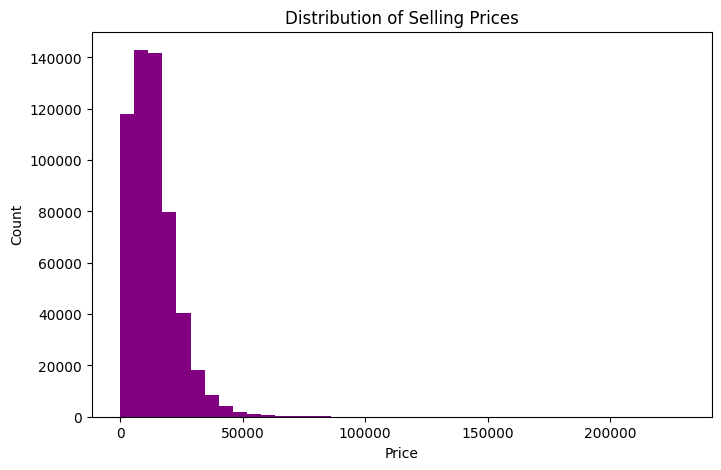

In [23]:
d['sellingprice'].plot(kind='hist', bins=40, figsize=(8,5),color="purple")
plt.title("Distribution of Selling Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

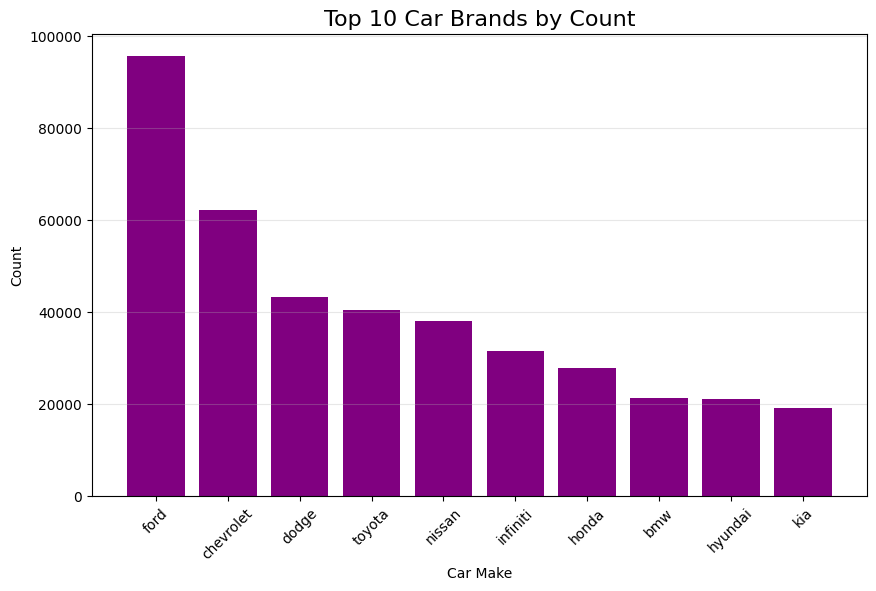

In [24]:
s = d['make'].value_counts().head(10)

plt.figure(figsize=(10,6))
bars = plt.bar(s.index, s.values, color='purple') 
plt.title("Top 10 Car Brands by Count", fontsize=16)
plt.xlabel("Car Make")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.show()

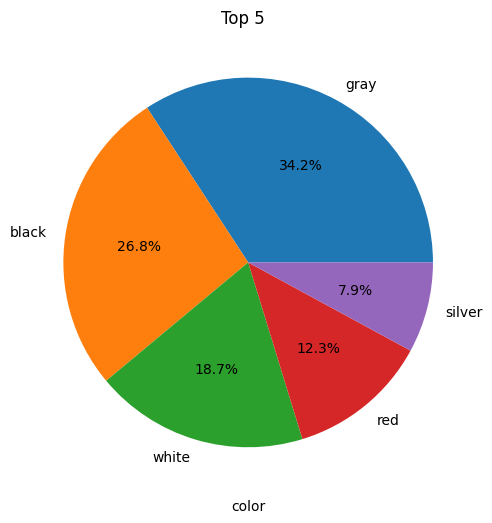

In [25]:
top_models = d['color'].value_counts().head(5)
plt.figure(figsize=(12,6))
top_models.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 5  ')
plt.xlabel('color')
plt.ylabel('')
plt.xticks(rotation=0)
plt.show()